# Okubo-Weiss Analysis: Global Front Properties

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import json, re
from scipy.stats import gaussian_kde
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from fronts.properties.colocation import colocate_fronts_with_properties



plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('Imports OK')

/home/lhoffma2/miniforge3/envs/fronts/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Imports OK


## 2. Load Pre-Computed Results

In [2]:
# ─── FILE PATHS ─── update these ───────────────────────────────────────────
results_dir  = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/group_fronts/v1/'          # directory with parquet / npy / json
coords_file  = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/coords/LLC_coords_lat_lon.nc'
ref_file     = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived/LLC4320_2012-11-09T12_00_00_gradb2_v1.nc'
run_tag      = 'v1_bin_A'  # run identifier for file naming
# ─────────────────────────────────────────────────────────────────────────────

# Extract timestamp from ref_file name
pattern = r'(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2})'
match   = re.search(pattern, ref_file)
if not match:
    raise ValueError(f'Cannot extract timestamp from: {ref_file}')
time_str      = match.group(1).replace('_', ':')   # 2012-11-09T12:00:00
time_str_safe = match.group(1).replace('-', '').replace(':', '')  # 20121109T12_00_00
time_str_safe = re.sub(r'T(\d{2})(\d{2})(\d{2})', r'T\1_\2_\3',
                       time_str.replace('-','').replace(':',''), count=1)
print(f'Timestep: {time_str}  (safe: {time_str_safe})')

# Construct standard filenames with run_tag
metadata_file  = Path(results_dir) / f'metadata_{time_str_safe}_{run_tag}.json'
labeled_file   = Path(results_dir) / f'labeled_fronts_global_{time_str_safe}_{run_tag}.npy'
geometry_file  = Path(results_dir) / f'global_front_geometry_{time_str_safe}_{run_tag}.parquet'
coloc_file     = Path(results_dir) / f'front_properties_{time_str_safe}_{run_tag}.parquet'

# Load metadata
with open(metadata_file) as f:
    metadata = json.load(f)
downsample_factor = metadata.get('downsample_factor', None)
print(f"Shape: {metadata['shape']},  Fronts: {metadata['num_fronts']:,}")
if downsample_factor:
    print(f'  ⚠️  Downsampled ×{downsample_factor}')

# Load label map
labeled_global = np.load(labeled_file)
print(f'labeled_global: {labeled_global.shape}')

# Load geometric properties
df_global = pd.read_parquet(geometry_file)
print(f'df_global: {len(df_global):,} fronts × {len(df_global.columns)} cols')

# Load colocation (enriched properties)
df_coloc = pd.read_parquet(coloc_file)
print(f'df_coloc: {len(df_coloc):,} fronts × {len(df_coloc.columns)} cols')

# Merge geometric + colocation data on front label
df_enriched = df_global.merge(df_coloc, left_on='label', right_on='flabel', how='inner')
print(f'df_enriched: {len(df_enriched):,} fronts × {len(df_enriched.columns)} cols')
print(f'  Columns: {list(df_enriched.columns)[:10]}...')

# Load coordinates
ds_coords  = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values
ds_coords.close()
if downsample_factor:
    lat_global = lat_global[::downsample_factor, ::downsample_factor]
    lon_global = lon_global[::downsample_factor, ::downsample_factor]

# Roll arrays so columns run -180 → +180
sample_row  = lat_global.shape[0] // 2
min_lon_col = int(np.argmin(lon_global[sample_row, :]))
shift       = -min_lon_col
if min_lon_col != 0:
    print(f'Rolling by {shift} cols to align longitude axis')
    lon_global    = np.roll(lon_global,    shift, axis=1)
    lat_global    = np.roll(lat_global,    shift, axis=1)
    labeled_global = np.roll(labeled_global, shift, axis=1)
else:
    print('No rolling needed')

print(f'\n✓ Pre-computed results loaded.  Array shape: {labeled_global.shape}')

Timestep: 2012-11-09T12:00:00  (safe: 20121109T12_00_00)
Shape: [12960, 17280],  Fronts: 135,654
labeled_global: (12960, 17280)
df_global: 135,654 fronts × 19 cols
df_coloc: 135,654 fronts × 156 cols
df_enriched: 135,654 fronts × 175 cols
  Columns: ['label', 'name', 'time', 'npix_x', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon']...
Rolling by -10464 cols to align longitude axis

✓ Pre-computed results loaded.  Array shape: (12960, 17280)


## 3. Load Physical Property Maps

In [3]:
properties_dir = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived'
version        = '1'
timestamp      = '2012-11-09T12_00_00'
property_names = ['gradb2', 'relative_vorticity', 'strain_mag', 'okubo_weiss', 'coriolis_f']
property_files = {name: (str(Path(properties_dir) / f'LLC4320_{timestamp}_{name}_v{version}.nc'), name) for name in property_names}

# Optional downsampling for display
downsample_factor = 1

In [4]:
import xarray as xr
from fronts.properties.colocation import _load_property_file

property_arrays = {}
for prop_name, src in property_files.items():
    arr = _load_property_file(src)          # handles .nc tuples, .npy, or arrays
    arr = arr.squeeze()                      # drop any singleton time/depth dims
    if downsample_factor:
        arr = arr[::downsample_factor, ::downsample_factor]
    if min_lon_col != 0:                     # same longitude roll as labeled array
        arr = np.roll(arr, shift, axis=1)
    property_arrays[prop_name] = arr
    src_label = src[0] if isinstance(src, (list, tuple)) else (
                    str(src) if not isinstance(src, np.ndarray) else '<array>')
    print(f"  {prop_name:25s}  shape={arr.shape}  "
          f"range=[{float(np.nanmin(arr)):.3g}, {float(np.nanmax(arr)):.3g}]")

print(f'\n✓ {len(property_arrays)} property arrays loaded and aligned')

  gradb2                     shape=(12960, 17280)  range=[4.79e-25, 1.58e-09]
  relative_vorticity         shape=(12960, 17280)  range=[-0.00158, 0.00118]
  strain_mag                 shape=(12960, 17280)  range=[8.58e-10, 0.00311]
  okubo_weiss                shape=(12960, 17280)  range=[-1.92e-06, 9.39e-06]
  coriolis_f                 shape=(12960, 17280)  range=[-0.000146, 0.000139]

✓ 5 property arrays loaded and aligned


## 4. Okubo-Weiss PDF: Weak vs Strong Fronts (by Grad-b²)

The Okubo-Weiss parameter W = strain² − ζ² discriminates strain-dominated (W > 0, hyperbolic) from rotation-dominated (W < 0, elliptic) flow.

Fronts/pixels are split into **weak** and **strong** groups using a percentile threshold on grad-b²:

* **Figure 1** — all ocean pixels from the global property arrays (sub-sampled for speed).
* **Figure 2** — per-front co-located means from `df_enriched`.

Each figure has two panels: **(a)** weak grad-b² group, **(b)** strong grad-b² group.  Both panels share the same OW axis so the shift in the distribution is immediately visible.

> Requires `'okubo_weiss'` and `'gradb2'` in `property_files` (Cell 5).

Figure 1  |  split at gradb2 = 8.52e-16 (50th pct)
  weak   pixels: 250,000
  strong pixels: 250,000


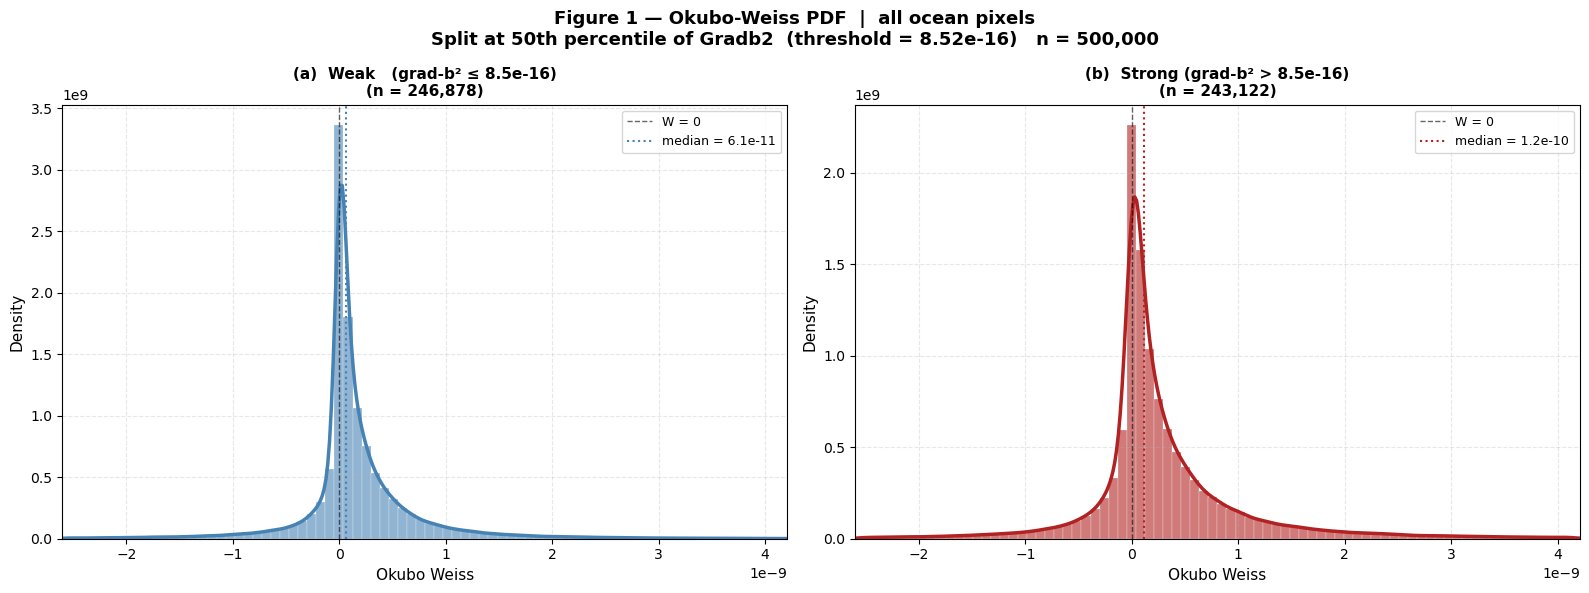


Figure 2  |  split at gradb2_mean = 5.22e-15 (50th pct)
  weak   fronts: 67,827
  strong fronts: 67,827


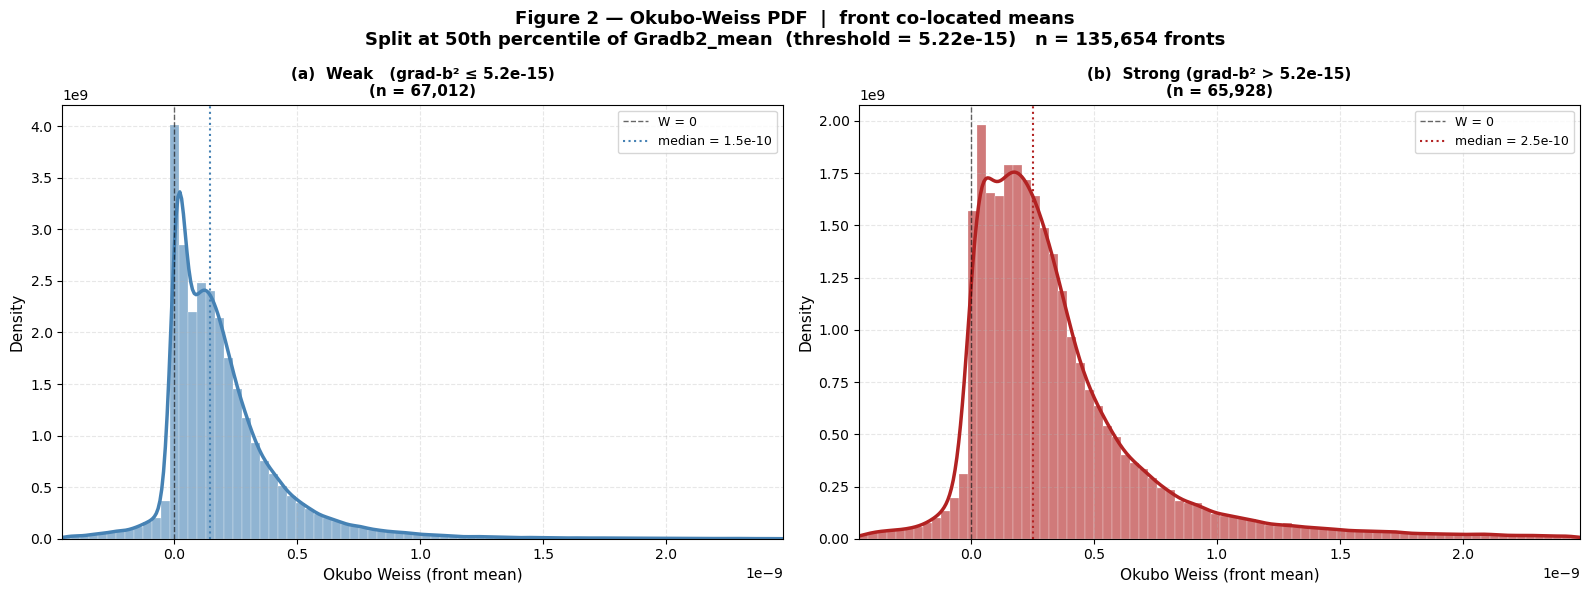

✓  Okubo-Weiss PDF plots done


In [5]:
# ─── SETTINGS ────────────────────────────────────────────────────────────────
OW_KEY       = 'okubo_weiss'
GRADB2_KEY   = 'gradb2'

# Percentile of gradb2 used to define the weak/strong boundary.
# 50 = median split;  use e.g. 33 / 67 for bottom-/top-third.
SPLIT_PCT    = 50

N_SAMPLE_GL  = 500_000   # max pixels for Figure 1; None = use all
N_BINS       = 80        # histogram bins
SHOW_KDE     = True      # overlay KDE curve on each panel
OW_PCT_CLIP  = 99        # clip OW x-axis to this percentile (drops extreme outliers)
# ─────────────────────────────────────────────────────────────────────────────

# ── Availability checks ───────────────────────────────────────────────────────
missing_arr = [k for k in (OW_KEY, GRADB2_KEY) if k not in property_arrays]
if missing_arr:
    raise KeyError(
        f'Keys missing from property_arrays: {missing_arr}\n'
        f'Add them to property_files in Cell 5 and re-run Cell 6.'
    )
missing_col = [k for k in (f'{OW_KEY}_mean', f'{GRADB2_KEY}_mean')
               if k not in df_enriched.columns]
if missing_col:
    raise KeyError(
        f'Co-located columns missing from df_enriched: {missing_col}\n'
        f'Make sure these properties were included before running Cell 8.'
    )

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — all ocean pixels
# ═══════════════════════════════════════════════════════════════════════════════
ow_gl    = property_arrays[OW_KEY].ravel().astype(float)
gb2_gl   = property_arrays[GRADB2_KEY].ravel().astype(float)

ok_gl    = np.isfinite(ow_gl) & np.isfinite(gb2_gl)
ow_gl, gb2_gl = ow_gl[ok_gl], gb2_gl[ok_gl]

if N_SAMPLE_GL and len(ow_gl) > N_SAMPLE_GL:
    idx    = np.random.default_rng(42).choice(len(ow_gl), N_SAMPLE_GL, replace=False)
    ow_gl, gb2_gl = ow_gl[idx], gb2_gl[idx]

thresh_gl   = float(np.percentile(gb2_gl, SPLIT_PCT))
weak_gl     = ow_gl[gb2_gl <= thresh_gl]
strong_gl   = ow_gl[gb2_gl >  thresh_gl]

print(f'Figure 1  |  split at gradb2 = {thresh_gl:.3g} ({SPLIT_PCT}th pct)')
print(f'  weak   pixels: {len(weak_gl):,}')
print(f'  strong pixels: {len(strong_gl):,}')

# shared OW axis limits
ow_all_gl = np.concatenate([weak_gl, strong_gl])
ow_lo_gl  = float(np.percentile(ow_all_gl, 100 - OW_PCT_CLIP))
ow_hi_gl  = float(np.percentile(ow_all_gl, OW_PCT_CLIP))

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig1.suptitle(
    f'Figure 1 — Okubo-Weiss PDF  |  all ocean pixels\n'
    f'Split at {SPLIT_PCT}th percentile of {GRADB2_KEY.replace("_"," ").title()}  '
    f'(threshold = {thresh_gl:.3g})   n = {len(ow_all_gl):,}',
    fontsize=13, fontweight='bold')

for ax, data, label, color in [
        (axes1[0], weak_gl,   f'(a)  Weak   (grad-b² ≤ {thresh_gl:.2g})',  'steelblue'),
        (axes1[1], strong_gl, f'(b)  Strong (grad-b² > {thresh_gl:.2g})',  'firebrick'),
]:
    clipped = data[(data >= ow_lo_gl) & (data <= ow_hi_gl)]
    ax.hist(clipped, bins=N_BINS, density=True,
            color=color, alpha=0.6, edgecolor='white', linewidth=0.3)
    if SHOW_KDE and len(clipped) > 20:
        from scipy.stats import gaussian_kde
        kde  = gaussian_kde(clipped, bw_method='scott')
        xs   = np.linspace(ow_lo_gl, ow_hi_gl, 400)
        ax.plot(xs, kde(xs), color=color, lw=2.5)
    ax.axvline(0, color='k', lw=1.0, ls='--', alpha=0.6, label='W = 0')
    ax.axvline(float(np.median(clipped)), color=color, lw=1.5, ls=':',
               label=f'median = {np.median(clipped):.2g}')
    ax.set_xlim(ow_lo_gl, ow_hi_gl)
    ax.set_xlabel(f'{OW_KEY.replace("_"," ").title()}', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{label}\n(n = {len(clipped):,})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — front co-located means
# ═══════════════════════════════════════════════════════════════════════════════
df_ow = df_enriched[[f'{OW_KEY}_mean', f'{GRADB2_KEY}_mean']].dropna().copy()
ow_fr  = df_ow[f'{OW_KEY}_mean'].values
gb2_fr = df_ow[f'{GRADB2_KEY}_mean'].values

thresh_fr  = float(np.percentile(gb2_fr, SPLIT_PCT))
weak_fr    = ow_fr[gb2_fr <= thresh_fr]
strong_fr  = ow_fr[gb2_fr >  thresh_fr]

print(f'\nFigure 2  |  split at gradb2_mean = {thresh_fr:.3g} ({SPLIT_PCT}th pct)')
print(f'  weak   fronts: {len(weak_fr):,}')
print(f'  strong fronts: {len(strong_fr):,}')

ow_all_fr = np.concatenate([weak_fr, strong_fr])
ow_lo_fr  = float(np.percentile(ow_all_fr, 100 - OW_PCT_CLIP))
ow_hi_fr  = float(np.percentile(ow_all_fr, OW_PCT_CLIP))

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig2.suptitle(
    f'Figure 2 — Okubo-Weiss PDF  |  front co-located means\n'
    f'Split at {SPLIT_PCT}th percentile of {GRADB2_KEY.replace("_"," ").title()}_mean  '
    f'(threshold = {thresh_fr:.3g})   n = {len(ow_all_fr):,} fronts',
    fontsize=13, fontweight='bold')

for ax, data, label, color in [
        (axes2[0], weak_fr,   f'(a)  Weak   (grad-b² ≤ {thresh_fr:.2g})',  'steelblue'),
        (axes2[1], strong_fr, f'(b)  Strong (grad-b² > {thresh_fr:.2g})',  'firebrick'),
]:
    clipped = data[(data >= ow_lo_fr) & (data <= ow_hi_fr)]
    ax.hist(clipped, bins=N_BINS, density=True,
            color=color, alpha=0.6, edgecolor='white', linewidth=0.3)
    if SHOW_KDE and len(clipped) > 20:
        kde  = gaussian_kde(clipped, bw_method='scott')
        xs   = np.linspace(ow_lo_fr, ow_hi_fr, 400)
        ax.plot(xs, kde(xs), color=color, lw=2.5)
    ax.axvline(0, color='k', lw=1.0, ls='--', alpha=0.6, label='W = 0')
    ax.axvline(float(np.median(clipped)), color=color, lw=1.5, ls=':',
               label=f'median = {np.median(clipped):.2g}')
    ax.set_xlim(ow_lo_fr, ow_hi_fr)
    ax.set_xlabel(f'{OW_KEY.replace("_"," ").title()} (front mean)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{label}\n(n = {len(clipped):,})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print('\u2713  Okubo-Weiss PDF plots done')


## 5. Joint PDFs: Grad-b² vs Relative Vorticity / Strain / Okubo-Weiss

Three-panel joint probability density plots with **grad-b² on the y-axis** (front strength) and each dynamical variable on the x-axis:

* **(a)** grad-b²  vs  relative vorticity
* **(b)** grad-b²  vs  strain magnitude
* **(c)** grad-b²  vs  Okubo-Weiss

**Figure 1** — all ocean pixels (sub-sampled).  **Figure 2** — per-front co-located means.

> Requires `'relative_vorticity'`, `'strain_mag'`, `'gradb2'`, and `'okubo_weiss'` in `property_files` (Cell 5).

Figure 1: 500,000 pixels
Figure 2: 135,654 fronts


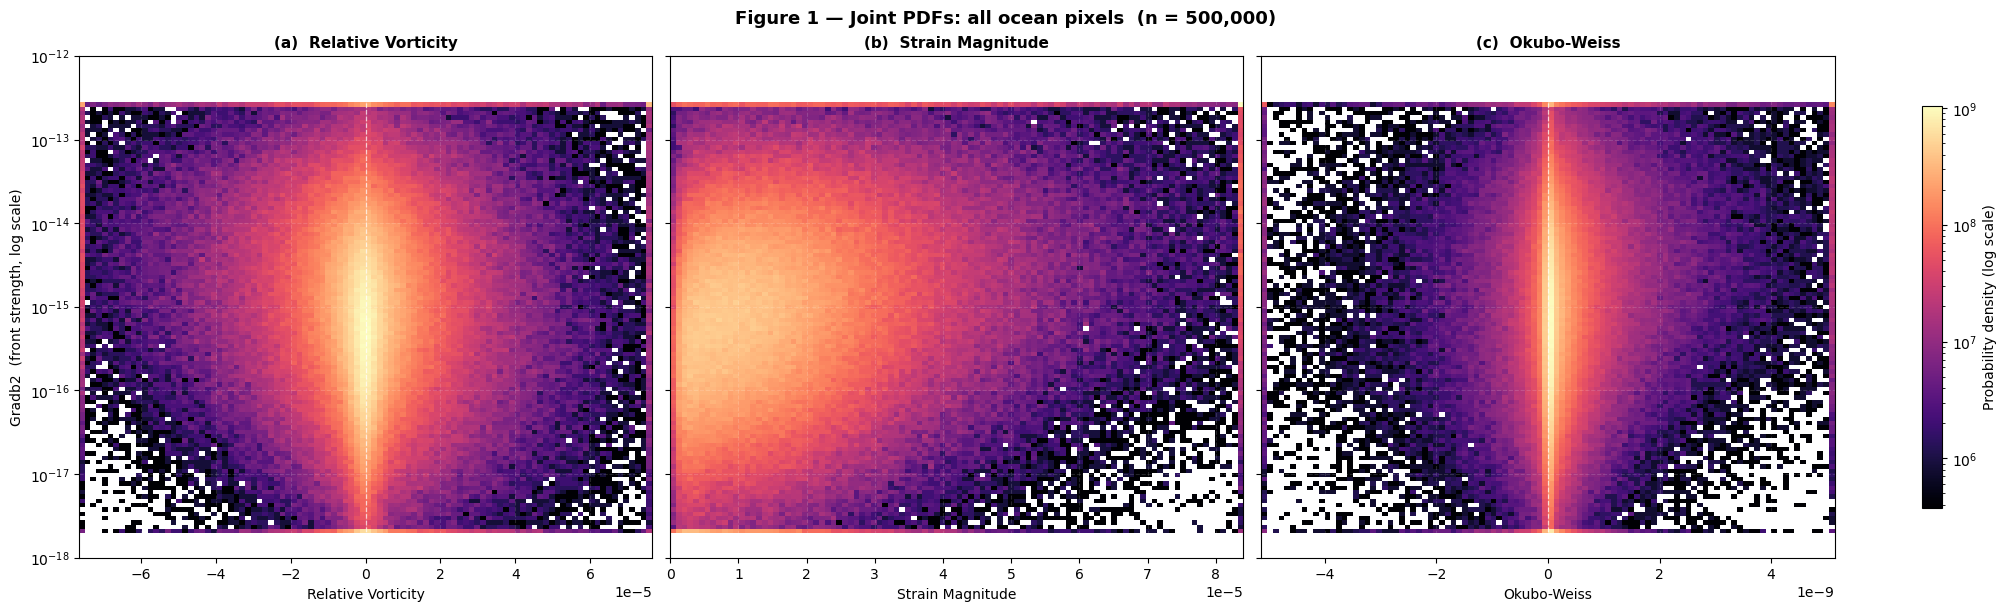

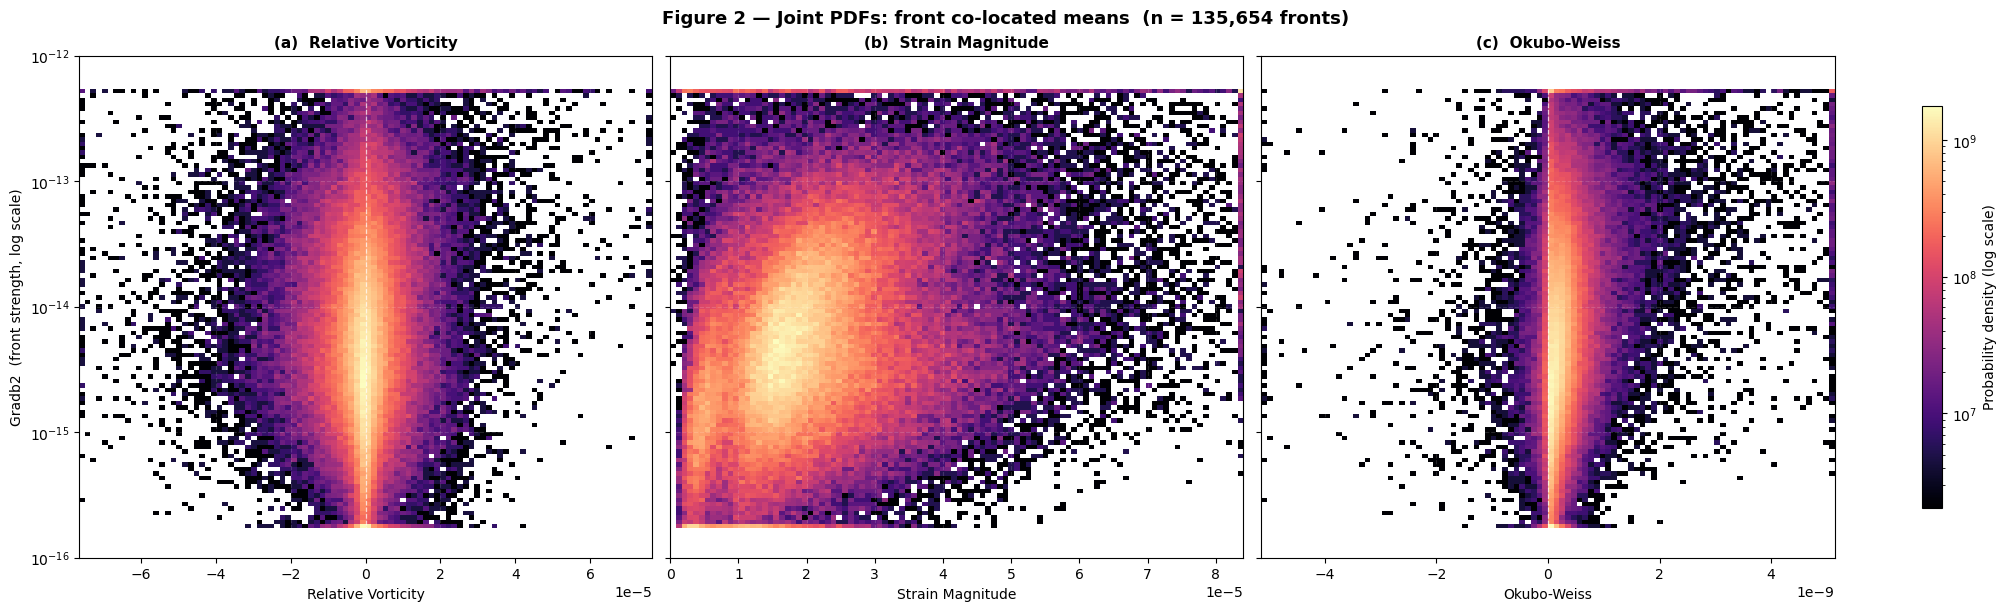

✓  Joint PDF (3-panel) plots done


In [7]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

# ─── SETTINGS ────────────────────────────────────────────────────────────────
VORT_KEY2    = 'relative_vorticity'
STRAIN_KEY2  = 'strain_mag'
OW_KEY3      = 'okubo_weiss'
GRADB2_KEY3  = 'gradb2'           # always on y-axis

N_SAMPLE_GL3 = 500_000            # max pixels for Figure 1
N_BINS3      = 100                # bins along each axis
PCT_CLIP3    = 99                 # percentile clip on each axis
LOG_Y3       = True               # log10 scale on the gradb2 y-axis
CMAP3        = 'magma'
# ─────────────────────────────────────────────────────────────────────────────

# Keys and their display properties: (key, label, symmetric_xaxis)
PANELS = [
    (VORT_KEY2,   r'Relative Vorticity',  True),   # signed → symmetric
    (STRAIN_KEY2, r'Strain Magnitude',    False),  # always >= 0
    (OW_KEY3,     r'Okubo-Weiss',         True),   # signed → symmetric
]

# ── Availability checks ───────────────────────────────────────────────────────
all_keys = [VORT_KEY2, STRAIN_KEY2, OW_KEY3, GRADB2_KEY3]
missing_arr = [k for k in all_keys if k not in property_arrays]
if missing_arr:
    raise KeyError(f'Keys missing from property_arrays: {missing_arr}\n'
                   f'Add them to property_files in Cell 5 and re-run Cell 6.')
missing_col = [f'{k}_mean' for k in all_keys if f'{k}_mean' not in df_enriched.columns]
if missing_col:
    raise KeyError(f'Co-located columns missing from df_enriched: {missing_col}\n'
                   f'Make sure these properties were included before running Cell 8.')

# ── Helper: single joint-PDF panel ───────────────────────────────────────────
def _joint_panel(ax, x_vals, y_vals, xlabel, symmetric_x,
                 x_lim, y_lim, log_y, n_bins, cmap):
    """2-D histogram of (x_vals, y_vals) with log-scale probability density."""
    y_lo, y_hi = y_lim
    x_lo, x_hi = x_lim

    y_p = np.log10(np.clip(y_vals, y_lo, y_hi)) if log_y else y_vals
    y_range = (np.log10(y_lo), np.log10(y_hi)) if log_y else (y_lo, y_hi)
    x_p = np.clip(x_vals, x_lo, x_hi)

    counts, xedges, yedges = np.histogram2d(
        x_p, y_p, bins=n_bins,
        range=[[x_lo, x_hi], list(y_range)],
        density=True,
    )
    counts = np.where(counts == 0, np.nan, counts)

    pm = ax.pcolormesh(
        xedges, yedges, counts.T,
        cmap=cmap,
        norm=LogNorm(vmin=np.nanmin(counts), vmax=np.nanmax(counts)),
        rasterized=True,
    )

    if symmetric_x:
        ax.axvline(0, color='white', lw=0.9, ls='--', alpha=0.7)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(*y_range)

    if log_y:
        ticks = np.arange(np.floor(y_range[0]), np.ceil(y_range[1]) + 1)
        ax.set_yticks(ticks)
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda v, _: f'$10^{{{v:.0f}}}$' if v == int(v) else ''))

    ax.grid(True, alpha=0.15, linestyle='--', color='white')
    return pm


# ── Build datasets ────────────────────────────────────────────────────────────
# Figure 1: raw global arrays, flattened
gl_data = {k: property_arrays[k].ravel().astype(float) for k in all_keys}
ok_gl3  = np.ones(len(gl_data[GRADB2_KEY3]), dtype=bool)
for v in gl_data.values():
    ok_gl3 &= np.isfinite(v)
ok_gl3 &= (gl_data[GRADB2_KEY3] > 0)   # log-y needs positive values
gl_data = {k: v[ok_gl3] for k, v in gl_data.items()}

if N_SAMPLE_GL3 and len(gl_data[GRADB2_KEY3]) > N_SAMPLE_GL3:
    idx3 = np.random.default_rng(1).choice(
        len(gl_data[GRADB2_KEY3]), N_SAMPLE_GL3, replace=False)
    gl_data = {k: v[idx3] for k, v in gl_data.items()}

# Figure 2: per-front co-located means
fr_cols = [f'{k}_mean' for k in all_keys]
df_jp2  = df_enriched[fr_cols].dropna().copy()
df_jp2  = df_jp2[df_jp2[f'{GRADB2_KEY3}_mean'] > 0]
fr_data = {k: df_jp2[f'{k}_mean'].values.astype(float) for k in all_keys}

print(f'Figure 1: {len(gl_data[GRADB2_KEY3]):,} pixels')
print(f'Figure 2: {len(fr_data[GRADB2_KEY3]):,} fronts')

# Shared gradb2 (y) limits — computed once per figure
def ylims(gb2_arr):
    return (float(np.percentile(gb2_arr, 100 - PCT_CLIP3)),
            float(np.percentile(gb2_arr, PCT_CLIP3)))

y_lim_gl = ylims(gl_data[GRADB2_KEY3])
y_lim_fr = ylims(fr_data[GRADB2_KEY3])

# Per-variable x-limits (computed from global pixels to keep figs comparable)
def xlims(arr, symmetric):
    if symmetric:
        lim = float(np.percentile(np.abs(arr[np.isfinite(arr)]), PCT_CLIP3))
        return (-lim, lim)
    else:
        return (0.0, float(np.percentile(arr[np.isfinite(arr) & (arr >= 0)], PCT_CLIP3)))

x_lims = {key: xlims(gl_data[key], sym) for key, _, sym in PANELS}

# ── Figure 1 ─────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(20, 6),
                            sharey=True, constrained_layout=True)
pms1 = []
for ax, (key, lbl, sym) in zip(axes1, PANELS):
    pm = _joint_panel(ax, gl_data[key], gl_data[GRADB2_KEY3],
                      lbl, sym, x_lims[key], y_lim_gl,
                      LOG_Y3, N_BINS3, CMAP3)
    pms1.append(pm)
    ax.set_title(f'({"abc"[PANELS.index((key,lbl,sym))]})  {lbl}',
                 fontsize=11, fontweight='bold')

axes1[0].set_ylabel(
    f'{GRADB2_KEY3.replace("_"," ").title()}  (front strength'
    + (', log scale)' if LOG_Y3 else ')'), fontsize=10)
for ax in axes1[1:]:           # y-label only on leftmost (sharey)
    ax.set_ylabel('')

fig1.colorbar(pms1[-1], ax=axes1, shrink=0.8, label='Probability density (log scale)')
fig1.suptitle(f'Figure 1 — Joint PDFs: all ocean pixels  (n = {len(gl_data[GRADB2_KEY3]):,})',
              fontsize=13, fontweight='bold')
plt.show()

# ── Figure 2 ─────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6),
                            sharey=True, constrained_layout=True)
pms2 = []
for ax, (key, lbl, sym) in zip(axes2, PANELS):
    pm = _joint_panel(ax, fr_data[key], fr_data[GRADB2_KEY3],
                      lbl, sym, x_lims[key], y_lim_fr,
                      LOG_Y3, N_BINS3, CMAP3)
    pms2.append(pm)
    ax.set_title(f'({"abc"[PANELS.index((key,lbl,sym))]})  {lbl}',
                 fontsize=11, fontweight='bold')

axes2[0].set_ylabel(
    f'{GRADB2_KEY3.replace("_"," ").title()}  (front strength'
    + (', log scale)' if LOG_Y3 else ')'), fontsize=10)
for ax in axes2[1:]:
    ax.set_ylabel('')

fig2.colorbar(pms2[-1], ax=axes2, shrink=0.8, label='Probability density (log scale)')
fig2.suptitle(f'Figure 2 — Joint PDFs: front co-located means  (n = {len(fr_data[GRADB2_KEY3]):,} fronts)',
              fontsize=13, fontweight='bold')
plt.show()
print('\u2713  Joint PDF (3-panel) plots done')
